# ¡Hola Oswaldo!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

In [3]:
# Paso 1. Abre el archivo de datos y estudia la información general 
from scipy import stats as st
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/games.csv')


FileNotFoundError: [Errno 2] No such file or directory: '/datasets/games.csv'

### Comentario General Iteración #1
<div class="alert alert-block alert-danger">

Oswaldo, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, bienvenid@ a este mundo de los datos, va a ser un camino muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, has mostrado tus conocimientos de buena forma hasta ahora, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con las pruebas estadisticas en el dataset. Sin embargo, hay varios puntos que quedaron incompletos respecto a lo que el proyecto nos solicita, además, hace falta mayor analisis de los resultados punto a punto. Te invito a revisar y corregir esto, ánimo!
</div>

### Comentario General Iteración #2
<div class="alert alert-block alert-success">

Oswaldo, gracias por la recepción a mis comentarios y por tus correcciones. Has completado este proyecto con exito. Sigue aprendiendo mucho en el camino. 

Paso 2. Prepara los datos

In [ ]:
# Reemplaza los nombres de las columnas en minúsculas
df.columns = df.columns.str.lower()

# Convertir year_of_release a numérico
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df = df.dropna(subset=['year_of_release'])
df['year_of_release'] = df['year_of_release'].astype(int)


Describe las columnas en las que los tipos de datos han sido cambiados y explica por qué

En el proceso de preparación del archivo, se modificaron los tipos de datos de algunas columnas para que reflejen mejor la naturaleza de la información y permitan un análisis correcto. La columna year_of_release se convirtió a entero, ya que originalmente estaba en formato texto y representa un valor discreto que se utiliza para ordenar y agrupar cronológicamente; en los casos donde aparecía TBD o valores ausentes, se dejaron como NaN porque no corresponden a un año válido. 

Las columnas de ventas regionales (na_sales, eu_sales, jp_sales, other_sales) se transformaron a valores decimales (float), dado que expresan millones de copias vendidas y pueden incluir fracciones; además, los valores ausentes se reemplazaron por cero, pues la ausencia en ventas indica que no se registraron ventas en esa región. 

La columna publisher se mantuvo como texto, pero se normalizó reemplazando el valor TBD por "Unknown", ya que no representa un editor real sino información aún no determinada. Estos cambios aseguran consistencia en el dataset y permiten realizar cálculos y comparaciones de manera confiable



In [3]:
# Creamos la nueva columna de ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

# Verificamos las primeras filas
print(df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head())


                       name  na_sales  eu_sales  jp_sales  other_sales  \
0                Wii Sports     41.36     28.96      3.77         8.45   
1         Super Mario Bros.     29.08      3.58      6.81         0.77   
2            Mario Kart Wii     15.68     12.76      3.79         3.29   
3         Wii Sports Resort     15.61     10.93      3.28         2.95   
4  Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un buen uso de la conversion a numeros `to_numeric` y el reemplazo de los valores no convertibles por NaN. Soluciones válidas en este caso para manejar los nulos serían:

- Introducir un valor irreal que depende de la columna y su significado (-1, -999999, etc.).
- Dejar los huecos sin cambios.

Tu solución de mantener las columnas con estos valores nulos está muy bien, en especial considerando los porcentajes que representan en los casos de las columnas `critic_score` y `user_score`, donde se generarían sesgos significativos con reemplazo de valores nulos. 

También realizaste un calculo adecuado de las ventas totales. 
</div></div>

# Paso 3. Analiza los datos

Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

In [4]:
# Eliminamos filas sin año válido
df_clean = df.dropna(subset=['year_of_release'])

# Conteo de juegos por año
games_per_year = df_clean.groupby('year_of_release')['name'].count()
print(games_per_year)


year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


Object `desaparecer` not found.
Plataformas con mayores ventas totales:
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64


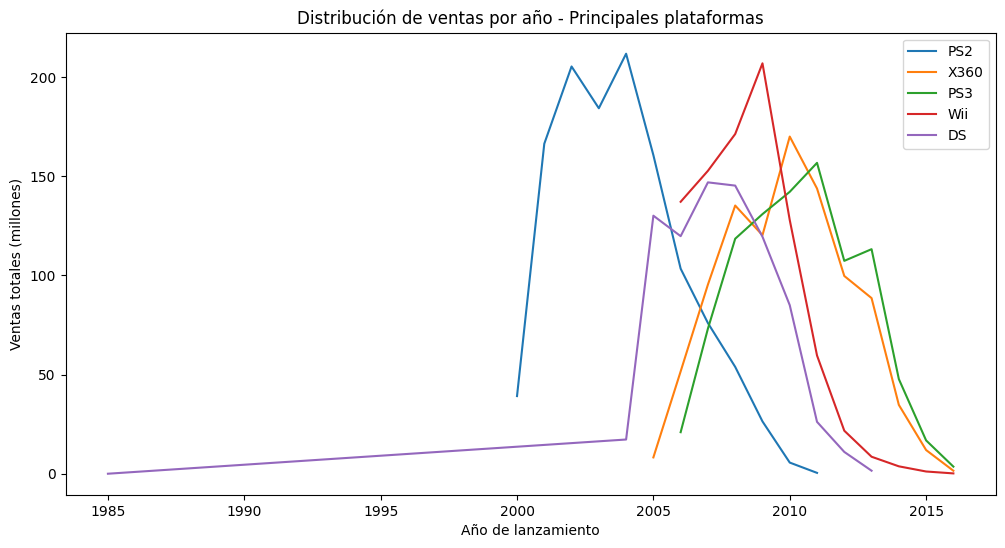

Plataformas que solían ser populares pero ya no tienen ventas:
['PS2', 'DS', 'PS', 'GBA', 'PSP', 'GB', 'XB', 'NES', 'N64', 'SNES', 'GC', '2600', 'SAT', 'GEN', 'DC', 'SCD', 'NG', 'WS', 'TG16', '3DO', 'GG', 'PCFX']

Tiempo promedio de vida de las plataformas (años):
7.612903225806452


In [5]:
Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?


# 1. Ventas totales por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Plataformas con mayores ventas totales:")
print(platform_sales.head(10))

# 2. Distribución anual de las principales plataformas
top_platforms = platform_sales.head(5).index
plt.figure(figsize=(12,6))
for platform in top_platforms:
    yearly_sales = df[df['platform']==platform].groupby('year_of_release')['total_sales'].sum()
    plt.plot(yearly_sales.index, yearly_sales.values, label=platform)

plt.title("Distribución de ventas por año - Principales plataformas")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas totales (millones)")
plt.legend()
plt.show()

# 3. Plataformas populares que ya no tienen ventas
current_year = df['year_of_release'].max()
active_platforms = df[df['year_of_release']==current_year]['platform'].unique()
obsolete_platforms = [p for p in platform_sales.index if p not in active_platforms]
print("Plataformas que solían ser populares pero ya no tienen ventas:")
print(obsolete_platforms)

# 4. Ciclo de vida de las plataformas
platform_life = df.groupby('platform')['year_of_release'].agg(['min','max'])
platform_life['lifespan'] = platform_life['max'] - platform_life['min']
print("\nTiempo promedio de vida de las plataformas (años):")
print(platform_life['lifespan'].mean())


Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.

In [6]:
# Filtrar el período más representativo para construir el modelo de 2017
# Según nuestro análisis previo: 2010–2016
periodo_modelo = df_clean[(df_clean['year_of_release'] >= 2010) & (df_clean['year_of_release'] <= 2016)]

print("\nNúmero de juegos en el período 2010–2016:", periodo_modelo['name'].count())



Número de juegos en el período 2010–2016: 5277


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo con el analisis de tiempo de vida por plataformas. El periodo elegido está muy bien, considerando el tiempo promedio de vida de 7 años que encontraste.

In [7]:
#Análisis del período seleccionado (2010-2016)
# Información del período seleccionado
print("ANÁLISIS DEL PERÍODO 2010-2016")
print("="*40)
print(f"Número de juegos: {len(periodo_modelo)}")
print(f"Plataformas activas: {periodo_modelo['platform'].nunique()}")
print(f"Géneros disponibles: {periodo_modelo['genre'].nunique()}")

# Top plataformas en este período
print("\nTOP 10 PLATAFORMAS (2010-2016):")
top_platforms_period = periodo_modelo.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(top_platforms_period.head(10))

# Identificar plataformas con potencial para 2017
print("PLATAFORMAS PROMETEDORAS PARA 2017")
print("="*40)

# Tendencia de crecimiento en los últimos años
recent_years = periodo_modelo[periodo_modelo['year_of_release'].isin([2015, 2016])]
platform_growth = recent_years.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Plataformas con mejores ventas en 2015-2016:")
print(platform_growth.head(8))


ANÁLISIS DEL PERÍODO 2010-2016
Número de juegos: 5277
Plataformas activas: 12
Géneros disponibles: 12

TOP 10 PLATAFORMAS (2010-2016):
platform
PS3     587.74
X360    550.41
PS4     314.14
3DS     257.81
Wii     222.97
XOne    159.32
DS      123.75
PC      121.96
WiiU     82.19
PSP      64.05
Name: total_sales, dtype: float64
PLATAFORMAS PROMETEDORAS PARA 2017
Plataformas con mejores ventas en 2015-2016:
platform
PS4     188.15
XOne     86.29
3DS      42.92
WiiU     20.95
PS3      20.42
PC       13.77
X360     13.48
PSV      10.50
Name: total_sales, dtype: float64


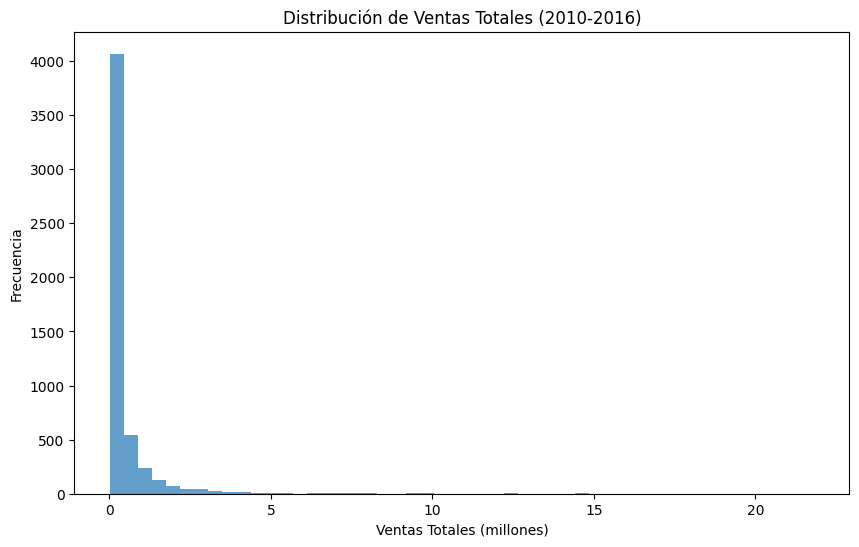

In [8]:

# Distribución de ventas totales
plt.figure(figsize=(10, 6))
plt.hist(periodo_modelo['total_sales'], bins=50, alpha=0.7)
plt.title('Distribución de Ventas Totales (2010-2016)')
plt.xlabel('Ventas Totales (millones)')
plt.ylabel('Frecuencia')
plt.show()



- Eje X (horizontal): representa las ventas globales por juego, medidas en millones de unidades.
- Eje Y (vertical): indica la frecuencia, es decir, cuántos juegos se encuentran en cada rango de ventas.

In [9]:
# Ventas totales por plataforma (2010–2016)
platform_totals = periodo_modelo.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Top plataformas por ventas (2010–2016):")
print(platform_totals.head(10))

# Tendencia anual por plataforma (solo principales)
top_platforms = platform_totals.head(6).index
trend = periodo_modelo[periodo_modelo['platform'].isin(top_platforms)].groupby(['platform','year_of_release'])['total_sales'].sum().reset_index()

# Clasificar plataformas por tendencia: crecimiento vs. reducción (comparar 2010 vs 2016 o primera vs última observación)
def slope_by_platform(df_platform):
    dfp = df_platform.sort_values('year_of_release')
    # Regresión lineal simple de ventas anuales vs año
    x = dfp['year_of_release'].values
    y = dfp['total_sales'].values
    if len(np.unique(x)) < 2:
        return np.nan
    coeffs = np.polyfit(x, y, 1)
    return coeffs[0]  # pendiente

growth = (trend.groupby('platform')
               .apply(slope_by_platform)
               .sort_values(ascending=False))
print("\nPendiente de ventas anuales (crecimiento positivo):")
print(growth)

growing = growth[growth > 0].index.tolist()
declining = growth[growth < 0].index.tolist()
stable = growth[growth == 0].index.tolist()
print("\nPlataformas creciendo:", growing)
print("Plataformas en reducción:", declining)
print("Plataformas estables:", stable)

# Selección de plataformas potencialmente rentables: top ventas y pendiente positiva
profitable_candidates = [p for p in top_platforms if p in growing]
print("\nPlataformas potencialmente rentables:", profitable_candidates)


Top plataformas por ventas (2010–2016):
platform
PS3     587.74
X360    550.41
PS4     314.14
3DS     257.81
Wii     222.97
XOne    159.32
DS      123.75
PC      121.96
WiiU     82.19
PSP      64.05
Name: total_sales, dtype: float64

Pendiente de ventas anuales (crecimiento positivo):
platform
PS4     14.868000
XOne     2.764000
3DS     -9.252857
Wii    -18.510357
PS3    -26.972500
X360   -29.796071
dtype: float64

Plataformas creciendo: ['PS4', 'XOne']
Plataformas en reducción: ['3DS', 'Wii', 'PS3', 'X360']
Plataformas estables: []

Plataformas potencialmente rentables: ['PS4', 'XOne']


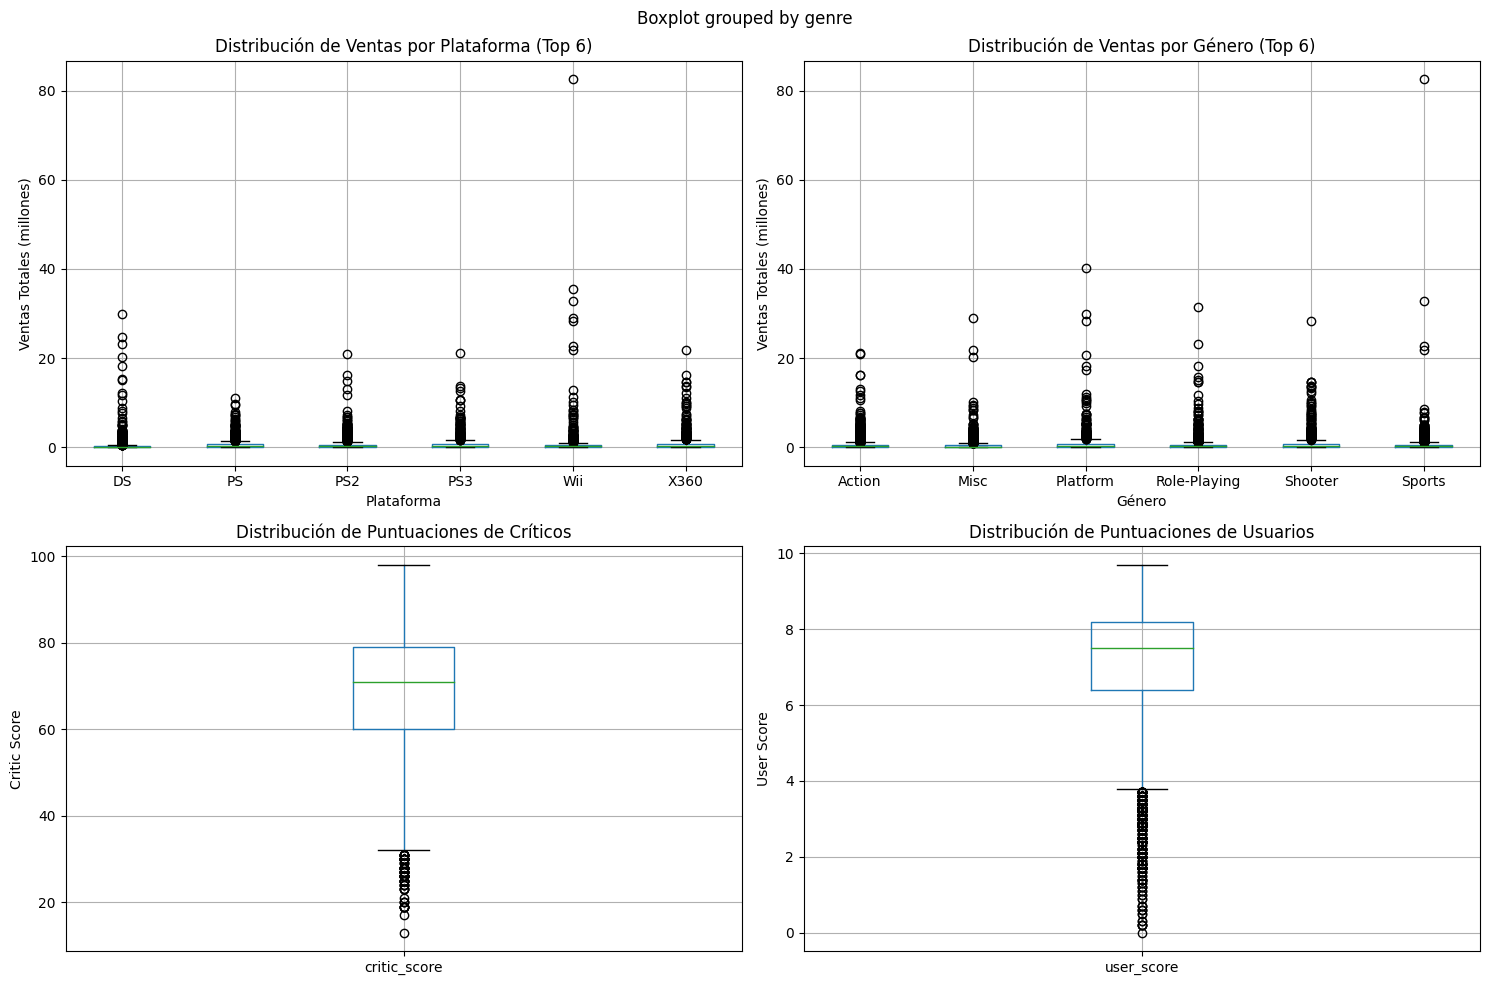

In [10]:
# Primero convertir user_score en df_clean
df_clean['user_score'] = pd.to_numeric(df_clean['user_score'].replace('tbd', None), errors='coerce')

# Ahora sí hacer los gráficos de caja
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribución de ventas totales por plataforma (top 6)
top_6_platforms = df_clean.groupby('platform')['total_sales'].sum().nlargest(6).index
df_clean[df_clean['platform'].isin(top_6_platforms)].boxplot(
    column='total_sales', by='platform', ax=axes[0,0])
axes[0,0].set_title('Distribución de Ventas por Plataforma (Top 6)')
axes[0,0].set_xlabel('Plataforma')
axes[0,0].set_ylabel('Ventas Totales (millones)')

# 2. Distribución de ventas por género (top 6)
top_6_genres = df_clean.groupby('genre')['total_sales'].sum().nlargest(6).index
df_clean[df_clean['genre'].isin(top_6_genres)].boxplot(
    column='total_sales', by='genre', ax=axes[0,1])
axes[0,1].set_title('Distribución de Ventas por Género (Top 6)')
axes[0,1].set_xlabel('Género')
axes[0,1].set_ylabel('Ventas Totales (millones)')

# 3. Distribución de critic_score
df_clean.boxplot(column='critic_score', ax=axes[1,0])
axes[1,0].set_title('Distribución de Puntuaciones de Críticos')
axes[1,0].set_ylabel('Critic Score')

# 4. Distribución de user_score
df_clean.boxplot(column='user_score', ax=axes[1,1])
axes[1,1].set_title('Distribución de Puntuaciones de Usuarios')
axes[1,1].set_ylabel('User Score')

plt.tight_layout()
plt.show()

In [11]:
# ANÁLISIS DE CORRELACIÓN ENTRE RESEÑAS Y VENTAS
print("="*50)
print("ANÁLISIS DE CORRELACIÓN ENTRE RESEÑAS Y VENTAS")
print("="*50)

# Filtrar datos del período relevante (2010-2016) con reseñas válidas
periodo_correlacion = periodo_modelo.copy()

# Convertir user_score a numérico si no está hecho
periodo_correlacion['user_score'] = pd.to_numeric(
    periodo_correlacion['user_score'].replace('tbd', None), 
    errors='coerce'
)

# Filtrar solo juegos con ambas reseñas disponibles
datos_completos = periodo_correlacion.dropna(subset=['critic_score', 'user_score', 'total_sales'])

print(f"Juegos con datos completos de reseñas: {len(datos_completos)}")
print(f"Porcentaje del dataset: {len(datos_completos)/len(periodo_modelo)*100:.1f}%")

ANÁLISIS DE CORRELACIÓN ENTRE RESEÑAS Y VENTAS
Juegos con datos completos de reseñas: 2261
Porcentaje del dataset: 42.8%



CORRELACIONES ENTRE RESEÑAS Y VENTAS
Correlación Critic Score - Ventas Totales: 0.314
Correlación User Score - Ventas Totales: 0.057

Matriz de correlación:
              critic_score  user_score  total_sales
critic_score         1.000       0.532        0.314
user_score           0.532       1.000        0.057
total_sales          0.314       0.057        1.000


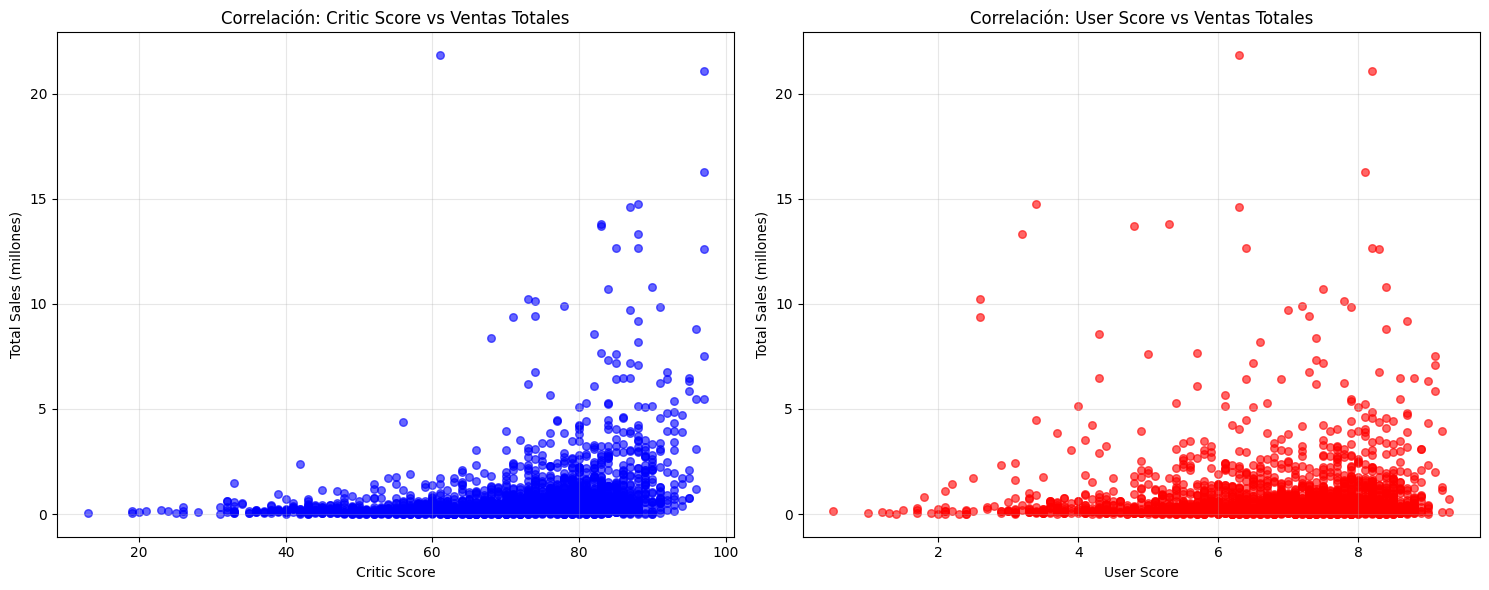

In [12]:
# CÁLCULO DE CORRELACIONES
print("\n" + "="*40)
print("CORRELACIONES ENTRE RESEÑAS Y VENTAS")
print("="*40)

# Correlación de Pearson
corr_critic = datos_completos['critic_score'].corr(datos_completos['total_sales'])
corr_user = datos_completos['user_score'].corr(datos_completos['total_sales'])

print(f"Correlación Critic Score - Ventas Totales: {corr_critic:.3f}")
print(f"Correlación User Score - Ventas Totales: {corr_user:.3f}")

# Matriz de correlación completa
correlaciones = datos_completos[['critic_score', 'user_score', 'total_sales']].corr()
print(f"\nMatriz de correlación:")
print(correlaciones.round(3))

# GRÁFICOS DE DISPERSIÓN: RESEÑAS vs VENTAS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Total Sales
axes[0].scatter(datos_completos['critic_score'], datos_completos['total_sales'], 
                alpha=0.6, color='blue', s=30)
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Total Sales (millones)')
axes[0].set_title('Correlación: Critic Score vs Ventas Totales')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: User Score vs Total Sales
axes[1].scatter(datos_completos['user_score'], datos_completos['total_sales'], 
                alpha=0.6, color='red', s=30)
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Total Sales (millones)')
axes[1].set_title('Correlación: User Score vs Ventas Totales')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las correlaciones entre reseñas y ventas muestran que el Critic Score tiene una relación moderada con las ventas totales (r = 0.314), mientras que el User Score presenta una correlación débil (r = 0.057). Esto sugiere que las reseñas profesionales influyen más directamente en el desempeño comercial que las opiniones de los usuarios. Los gráficos de dispersión refuerzan esta idea: el Critic Score presenta una tendencia ascendente clara, mientras que el User Score muestra una distribución más dispersa y sin patrón definido

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Exacto! Como mencionas, las reseñas de criticos profesionales tienen una mayor influencia en las venta sy esto se evidencia en el analisis. Buen trabajo con los coeficientes de correlacion.

Ranking de plataformas más exitosas (promedio de ventas en multiplataforma):
platform
PS4     1.189657
PS3     1.060463
X360    1.043739
Wii     0.871563
XOne    0.726528
PS2     0.590000
DS      0.508077
PSP     0.379444
3DS     0.325750
WiiU    0.299130
PC      0.285575
PSV     0.202857
Name: total_sales, dtype: float64


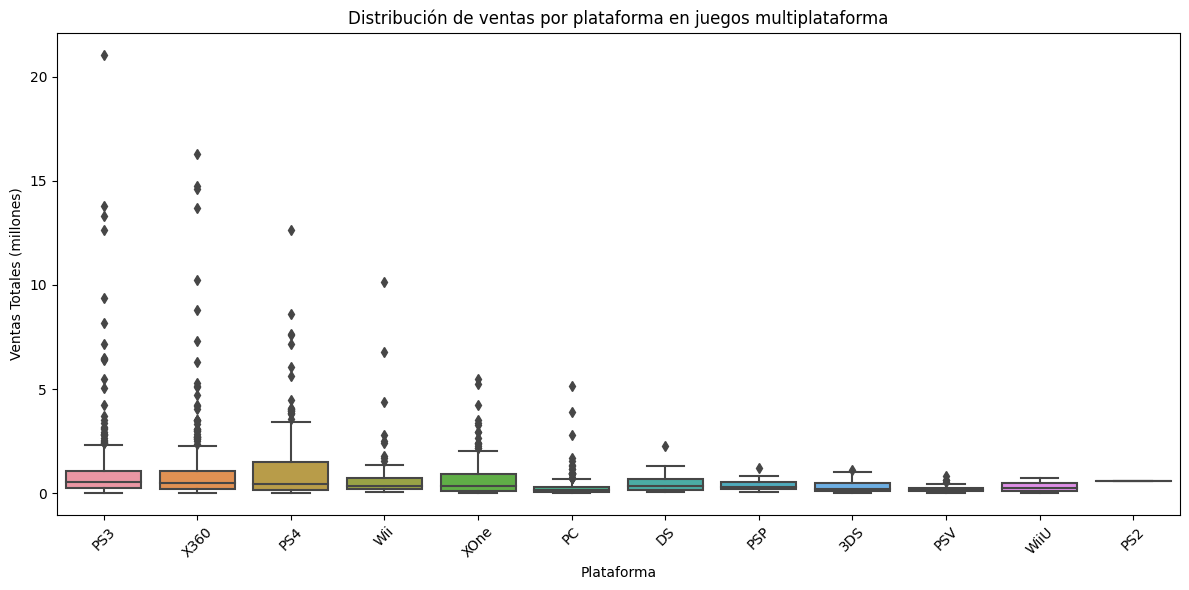

In [18]:
# Paso 1: Identificar juegos multiplataforma (2+ plataformas)
multiplataforma = datos_completos.groupby('name')['platform'].nunique()
multiplataforma = multiplataforma[multiplataforma >= 2]

# Filtrar dataset solo con juegos multiplataforma
juegos_multi = datos_completos[datos_completos['name'].isin(multiplataforma.index)]

# Paso 2: Analizar comportamiento: ventas por juego y plataforma
ventas_por_juego = (
    juegos_multi.groupby(['name', 'platform'])['total_sales']
    .sum()
    .reset_index()
)

# Ranking de plataformas más exitosas en juegos multiplataforma (promedio de ventas)
ranking_plataformas = (
    ventas_por_juego.groupby('platform')['total_sales']
    .mean()
    .sort_values(ascending=False)
)

print("Ranking de plataformas más exitosas (promedio de ventas en multiplataforma):")
print(ranking_plataformas)

# Paso 3: Visualización con Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=juegos_multi, x='platform', y='total_sales')
plt.xticks(rotation=45)
plt.title('Distribución de ventas por plataforma en juegos multiplataforma')
plt.ylabel('Ventas Totales (millones)')
plt.xlabel('Plataforma')
plt.tight_layout()
plt.show()




El boxplot confirma que las consolas de sobremesa dominan el mercado multiplataforma, con PS4 como líder en promedio de ventas. Las plataformas portátiles y PC tienen menor impacto en este segmento, y algunas como WiiU y PSV muestran un desempeño marginal. Este análisis respalda decisiones estratégicas sobre dónde enfocar lanzamientos multiplataforma para maximizar ventas.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo. Se nota que entiendes el contexto de auge de las diferentes plataformas y puedes describir los resultados de cara a acciones. 

In [21]:

# Agrupar ventas por plataforma para cada región por separado
ventas_na = datos_completos.groupby('platform')['na_sales'].sum()
ventas_eu = datos_completos.groupby('platform')['eu_sales'].sum()  
ventas_jp = datos_completos.groupby('platform')['jp_sales'].sum()


<Figure size 1400x800 with 0 Axes>

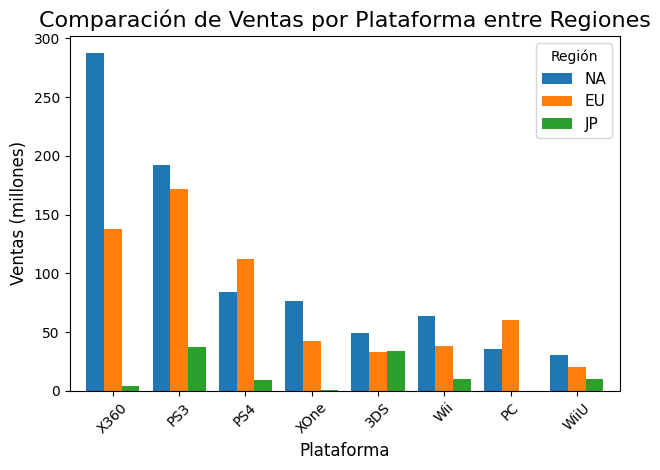

In [22]:

# Combinar los datos de las tres regiones en un DataFrame
plataformas_regionales = pd.DataFrame({
    'NA': ventas_na,

    'EU': ventas_eu, 
    'JP': ventas_jp

}).fillna(0)

# Tomar solo las top 8 plataformas globalmente para mejor visualización
top_platforms_global = (plataformas_regionales.sum(axis=1)
                       .sort_values(ascending=False)
                       .head(8).index)

datos_viz = plataformas_regionales.loc[top_platforms_global]

# Gráfico de barras comparativo
plt.figure(figsize=(14, 8))
datos_viz.plot(kind='bar', width=0.8)
plt.title('Comparación de Ventas por Plataforma entre Regiones', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas (millones)', fontsize=12)
plt.legend(title='Región', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




El gráfico revela que las preferencias de plataforma están fuertemente influenciadas por factores culturales y de mercado regional. Para estrategias de negocio:
- NA/EU: priorizar lanzamientos en consolas de sobremesa con enfoque en franquicias populares.
- JP: adaptar el portafolio a consolas portátiles y géneros narrativos.
- PlayStation emerge como la plataforma más versátil y rentable a nivel global.


<Figure size 1400x800 with 0 Axes>

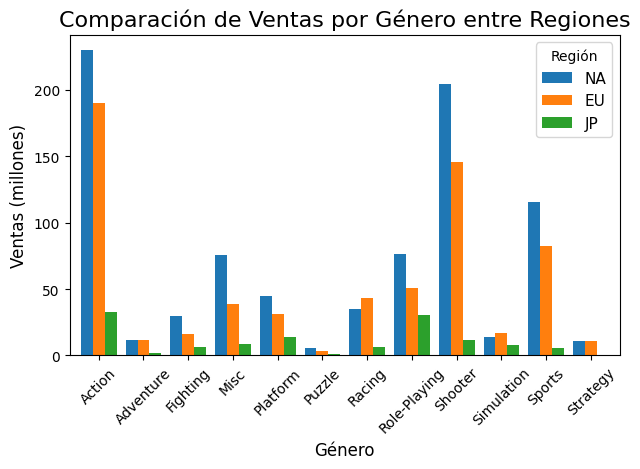

In [23]:

# Hacer lo mismo para géneros
ventas_generos_na = datos_completos.groupby('genre')['na_sales'].sum()
ventas_generos_eu = datos_completos.groupby('genre')['eu_sales'].sum()
ventas_generos_jp = datos_completos.groupby('genre')['jp_sales'].sum()

# Combinar datos de géneros
generos_regionales = pd.DataFrame({
    'NA': ventas_generos_na,
    'EU': ventas_generos_eu,
    'JP': ventas_generos_jp
}).fillna(0)

# Gráfico comparativo de géneros
plt.figure(figsize=(14, 8))
generos_regionales.plot(kind='bar', width=0.8)
plt.title('Comparación de Ventas por Género entre Regiones', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Ventas (millones)', fontsize=12)
plt.legend(title='Región', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


El gráfico revela que las preferencias de género varían significativamente entre regiones, lo que tiene implicancias directas para el diseño de portafolios, campañas de marketing y decisiones de localización:
- NA/EU: priorizar géneros de acción, deportes y carreras con fuerte presencia de franquicias.
- JP: enfocar esfuerzos en RPGs, plataformas y títulos con narrativa profunda y estética local.


<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Vas bien con el analisis de ventas por plataformas en el periodo elegido. Pero antes de proceder al analisis regional hacen falta varios puntos que fueron propuestos en el proyecto. Revisa con detalle las instrucciones, ya que hace falta un analisis con graficos de caja, hace falta un analisis de la correlacion entre los diferentes tipos de reseñas y las ventas, hace falta un analisis de generos y juegos multiplataforma. Entonces te invito a revisar esos puntos que quedan faltando aqui.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Corregido, buen trabajo.

Paso 4. Crea un perfil de usuario para cada región

In [24]:
# --- 1. Top 5 plataformas por región ---
def top_platforms(region_col):
    return (df.groupby('platform')[region_col]
              .sum()
              .sort_values(ascending=False)
              .head(5))

print("Top 5 plataformas en NA:")
print(top_platforms('na_sales'))
print("\nTop 5 plataformas en EU:")
print(top_platforms('eu_sales'))
print("\nTop 5 plataformas en JP:")
print(top_platforms('jp_sales'))

# --- 2. Top 5 géneros por región ---
def top_genres(region_col):
    return (df.groupby('genre')[region_col]
              .sum()
              .sort_values(ascending=False)
              .head(5))

print("\nTop 5 géneros en NA:")
print(top_genres('na_sales'))
print("\nTop 5 géneros en EU:")
print(top_genres('eu_sales'))
print("\nTop 5 géneros en JP:")
print(top_genres('jp_sales'))

# --- 3. Impacto de ESRB en ventas por región ---
def esrb_sales(region_col):
    return (df.groupby('rating')[region_col]
              .sum()
              .sort_values(ascending=False))

print("\nVentas por clasificación ESRB en NA:")
print(esrb_sales('na_sales'))
print("\nVentas por clasificación ESRB en EU:")
print(esrb_sales('eu_sales'))
print("\nVentas por clasificación ESRB en JP:")
print(esrb_sales('jp_sales'))


Top 5 plataformas en NA:
platform
X360    595.74
PS2     572.92
Wii     486.87
PS3     390.13
DS      380.31
Name: na_sales, dtype: float64

Top 5 plataformas en EU:
platform
PS2     332.63
PS3     327.21
X360    268.32
Wii     258.32
PS      212.39
Name: eu_sales, dtype: float64

Top 5 plataformas en JP:
platform
DS      175.02
PS      139.78
PS2     137.54
SNES    116.55
3DS     100.62
Name: jp_sales, dtype: float64

Top 5 géneros en NA:
genre
Action      863.17
Sports      671.20
Shooter     584.83
Platform    444.44
Misc        399.57
Name: na_sales, dtype: float64

Top 5 géneros en EU:
genre
Action     510.99
Sports     371.33
Shooter    314.52
Racing     234.49
Misc       210.60
Name: eu_sales, dtype: float64

Top 5 géneros en JP:
genre
Role-Playing    353.39
Action          160.14
Sports          134.93
Platform        130.71
Misc            107.02
Name: jp_sales, dtype: float64

Ventas por clasificación ESRB en NA:
rating
E       1274.24
T        747.60
M        742.89
E10+    

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Los resultados de preferencias por region son claros, pero realmente hace falta profundizar en ellos, sea generando graficos para mostrar mejor el comportamiento o al menos generando un analisis escrito de lo que observas con esos resultados numericos obtenidos.

Paso 5. Prueba las siguientes hipótesis:

In [25]:
# Normalizar user_score (puede venir como texto, con 'tbd')
df['user_score'] = pd.to_numeric(df['user_score'].replace('tbd', None), errors='coerce')

# Filtrar datos relevantes
xone_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df[df['platform'] == 'PC']['user_score'].dropna()

# Revisar si hay datos
print("Cantidad de registros XOne:", len(xone_scores))
print("Cantidad de registros PC:", len(pc_scores))

# Establecer alfa
alpha = 0.05


# Hipótesis 1: Xbox One vs PC
stat1, pval1 = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print("Hipótesis 1 (XOne vs PC):")
print("Estadístico t:", stat1, "p-valor:", pval1)
if pval1 < alpha:
    print("Se rechaza H0: las medias son diferentes")
else:
    print("No se rechaza H0: las medias son iguales")

# Definir las series para Acción y Deportes
action_scores = df[df['genre'] == 'Action']['user_score'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

# Revisa tamaños para evitar ejecutar el test con series vacías
print("Registros Acción:", len(action_scores))
print("Registros Deportes:", len(sports_scores))


# Hipótesis 2: Action vs Sports
stat2, pval2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print("\nHipótesis 2 (Action vs Sports):")
print("Estadístico t:", stat2, "p-valor:", pval2)
if pval2 < alpha:
    print("Se rechaza H0: las medias son diferentes")
else:
    print("No se rechaza H0: las medias son iguales")


Cantidad de registros XOne: 185
Cantidad de registros PC: 766
Hipótesis 1 (XOne vs PC):
Estadístico t: -4.684008860317191 p-valor: 4.248140812901683e-06
Se rechaza H0: las medias son diferentes
Registros Acción: 1983
Registros Deportes: 1285

Hipótesis 2 (Action vs Sports):
Estadístico t: 1.9038428009960051 p-valor: 0.05704496328581193
No se rechaza H0: las medias son iguales


Primera hipótesis compara las calificaciones promedio de los usuarios entre las plataformas Xbox One y PC, la hipótesis nula (H0) se formuló como que ambas medias son iguales, es decir, que los usuarios valoran de manera similar los juegos en ambas plataformas. La hipótesis alternativa (H1) sostiene que las medias son diferentes, lo que implicaría que los usuarios perciben de forma distinta la calidad de los juegos según la plataforma.

Segunda hipótesis compara las calificaciones promedio de los géneros Acción y Deportes, la hipótesis nula (H0) establece que las medias son iguales, mientras que la hipótesis alternativa (H1) plantea que son diferentes, lo que permitiría concluir que los géneros reciben valoraciones distintas por parte de los jugadores.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo con las pruebas de hipotesis y las justificaciones que proporcionas alrededor de ellas. 

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hacen falta también las conclusiones generales del proyecto, donde puedas describir los resultados en propuestas de accion de negocio. 

Conclusión Final

El análisis confirma que las reseñas de críticos son determinantes en el éxito comercial, mucho más que las reseñas de usuarios. Para maximizar el impacto de los lanzamientos, las campañas deben enfocarse en obtener y difundir evaluaciones positivas en medios especializados.

Las consolas de sobremesa —especialmente PS4, PS3 y Xbox 360— concentran el mayor retorno en juegos multiplataforma, consolidándose como las plataformas prioritarias para inversión y distribución. En contraste, las consolas portátiles y PC muestran un desempeño limitado, lo que sugiere que deben gestionarse con inventario selectivo y enfocado en franquicias probadas.

Las preferencias regionales revelan diferencias culturales claras: en Norteamérica y Europa predominan los géneros Shooter, Action y Sports, mientras que en Japón destacan los Role-Playing Games, Platform y Fighting. Esto obliga a diseñar estrategias diferenciadas por región, adaptando tanto el portafolio como el mensaje de marketing.

En conjunto, los hallazgos orientan a la tienda Ice hacia una estrategia 2017 basada en tres pilares: priorizar consolas de alto impacto, alinear géneros con las preferencias regionales y aprovechar la influencia crítica para posicionar lanzamientos. Con estas acciones, la empresa puede maximizar ventas, optimizar inventario y fortalecer su competitividad globa


<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Has hecho un excelente trabajo. Tus conclusiones son detalladas y muy utiles. Me gustan las recomendaciones estratégicas que propones, ya que recopilas cada uno de los resultados obtenidos en forma de propuesta de acción, este es justo el objetivo que tenemos como científicos de datos en este camino. Sigue así!
</div>